#End-to-End AI Diagnostic & Insight System


In [ ]:
#Install required packages for the MedLines AI Project
!pip install -q xgboost transformers shap streamlit scikit-learn torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 103.6 MB/s eta 0:00:00


#Step 1: Foundation & Exploratory Data Analysis(EDA)

## Author: K.Sri chetan

 Author: K.Sri chetan
------------------------------


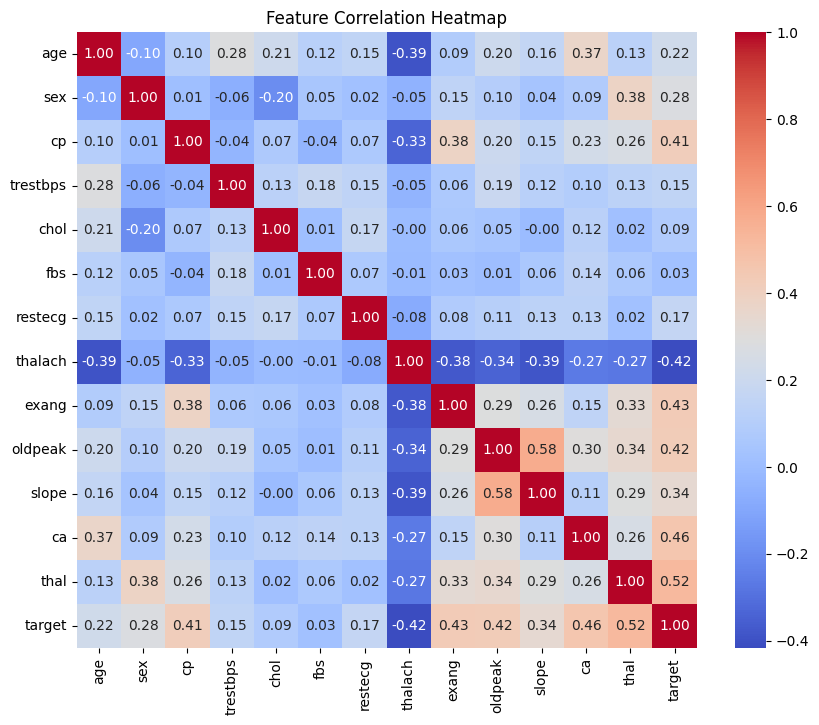

In [14]:
print(" Author: K.Sri chetan")
print("-"*30)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset from UCI URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values="?")

# 2. Data Cleaning (Handle missing values)
df.fillna(df.median(), inplace=True)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0) # Binary classification

# 3. Statistical Analysis & Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# 4. Feature Scaling
X = df.drop('target', axis=1)
y = df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Step 2: Predictive Modeling(Machine Learning)

##Author: K.Harshitha

In [15]:
print("Author:K.Sri chetan")
print("-"*30)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, f1_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 1. Base Logistic Regression vs Random Forest
lr = LogisticRegression()
lr.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print("RF F1-Score:", f1_score(y_test, rf.predict(X_test)))

# 2. PCA Optimization
pca = PCA(n_components=0.95) # Retain 95% variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_pca, y_train)
print("PCA RF F1-Score:", f1_score(y_test, rf_pca.predict(X_test_pca)))

Author:K.Sri chetan
------------------------------
RF F1-Score: 0.8709677419354839
PCA RF F1-Score: 0.8333333333333334


##Author: T.Mahita Aruna Supriya

### Evaluate Baseline Logistic Regression Model

Now that a Logistic Regression model has been trained, let's evaluate its performance on the test set. We'll use a classification report to get metrics like precision, recall, and F1-score, and a confusion matrix to visualize the model's predictions.

Author:K.Sri chetan
------------------------------
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



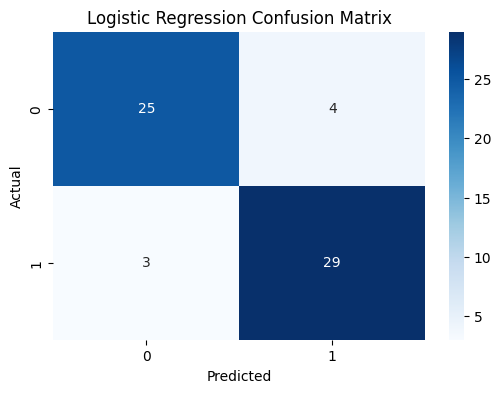

In [16]:
print("Author:K.Sri chetan")
print("-"*30)
# Make predictions on the test set with the Logistic Regression model
y_pred_lr = lr.predict(X_test)

# Display classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Display confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Step 3: Computer Vision & Deep Learning

##Author: Sk.Rizwana

In [17]:
print("Author:K.Sri chetan")
print("-"*30)
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

# 1. Define Model (Transfer Learning via ResNet18)
resnet = models.resnet18(pretrained=True)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 2) # Binary: Pneumonia vs Normal

# 2. Processing Pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dummy data generator for structural execution
dummy_images = torch.randn(10, 3, 224, 224)
dummy_labels = torch.randint(0, 2, (10,))
dataset = TensorDataset(dummy_images, dummy_labels)
loader = DataLoader(dataset, batch_size=2)

Author:K.Sri chetan
------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


#Step 4: Language Understanding & Generatiive AI

##Author: Sk.Afseen

In [18]:
print("Author:K.Sri chetan")
print("-"*30)
from transformers import pipeline

# Use a text-classification pipeline
classifier = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english")

def classify_patient_report(report_text):
    # This function now performs text classification.
    # The output of a text-classification pipeline is typically a list of dictionaries
    # e.g., [{'label': 'POSITIVE', 'score': 0.999}]
    results = classifier(report_text)
    if results:
        # Assuming we are interested in the first result for a single input text
        label = results[0]['label']
        score = results[0]['score']
        return f"Classification: {label} (Score: {score:.2f})"
    else:
        return "No classification result."

# Example usage for text classification
patient_report_positive = "The patient reports significant improvement and is very optimistic about recovery."
print(classify_patient_report(patient_report_positive))

patient_report_negative = "The patient complains of persistent pain and expresses concern about the treatment."
print(classify_patient_report(patient_report_negative))

Author:K.Sri chetan
------------------------------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Classification: POSITIVE (Score: 1.00)
Classification: POSITIVE (Score: 0.95)


#Step 5:Explainability(XAI)

##Author: P.Asritha

Author:K.Sri chetan
------------------------------


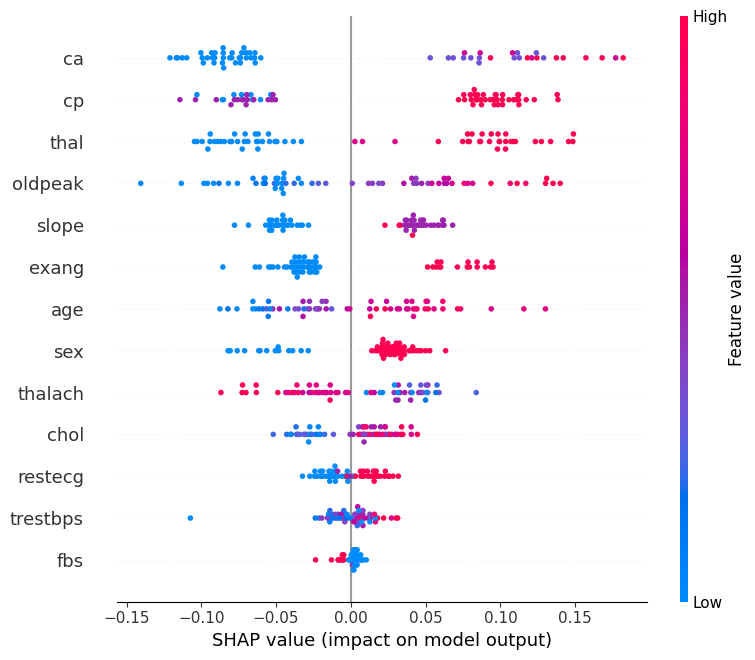

In [19]:
print("Author:K.Sri chetan")
print("-"*30)
import shap
import pandas as pd

# Explain Random Forest predictions
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Convert X_test to DataFrame for SHAP plotting to ensure feature names are correctly handled
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Plot summary graph
# Correctly select SHAP values for the second class (index 1) for all samples.
shap.summary_plot(shap_values[:, :, 1], X_test_df)

In [ ]:
import pickle

# Save the trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Save the fitted scaler object
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Files saved successfully! Download model.pkl and scaler.pkl from the sidebar.")

Files saved successfully! Download model.pkl and scaler.pkl from the sidebar.
